# Jane Street 模型训练 - LightGBM

## 为什么选择LightGBM？

### LightGBM的优势

**1. 训练速度快**
- 使用基于直方图的算法，比传统方法更快
- 支持GPU加速，在大数据集上尤其明显
- 内存效率高，可以处理大规模数据

**2. 性能优秀**
- 在表格数据上通常表现最佳
- 处理缺失值能力强
- 对类别特征有专门优化

**3. 灵活性高**
- 支持自定义损失函数和评估指标
- 丰富的参数可以调优
- 社区活跃，文档完善

### 适用场景

LightGBM特别适合：
- 结构化/表格数据（如本项目的金融数据）
- 大规模数据集（数百万样本）
- 需要快速迭代和实验的场景

### 与其他模型的对比

| 模型 | 训练速度 | 预测速度 | 内存占用 | 表调复杂度 | 推荐场景 |
|------|---------|---------|---------|-----------|----------|
| LightGBM | 很快 | 很快 | 低 | 中等 | 表格数据，大规模 |
| XGBoost | 快 | 快 | 中 | 中等 | 表格数据，稳定性 |
| 神经网络 | 慢 | 快 | 高 | 高 | 非线性关系，复杂模式 |

## 1. 环境设置

In [12]:
import numpy as np
import pandas as pd
import polars as pl
from pathlib import Path
import warnings
import joblib
import gc
from tqdm import tqdm

import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# 设置路径
# 使用相对路径
DATA_PATH = Path('../Dataset')
PROCESSED_PATH = Path('./processed_data')
MODEL_OUTPUT_PATH = Path('./models')

# 创建模型输出目录
MODEL_OUTPUT_PATH.mkdir(exist_ok=True, parents=True)

print(f"数据路径: {DATA_PATH}")
print(f"处理后的数据路径: {PROCESSED_PATH}")
print(f"模型输出路径: {MODEL_OUTPUT_PATH}")

数据路径: ../Dataset
处理后的数据路径: processed_data
模型输出路径: models


## 2. 配置参数

### 关键配置说明

**训练参数：**
- `N_FOLDS`: K折交叉验证的折数（推荐5折）
- `EPOCHS`: 训练轮数（LightGBM中是n_estimators）
- `EARLY_STOPPING_ROUNDS`: 早停轮数

**数据参数：**
- `VALIDATION_DATES`: 验证集天数
- `SKIP_DATES`: 跳过的开始天数（可选）

In [13]:
class CONFIG:
    # 数据路径
    TRAIN_FILE = PROCESSED_PATH / 'training.parquet'
    VALID_FILE = PROCESSED_PATH / 'validation.parquet'
    
    # 特征列
    FEATURE_COLS = [f"feature_{i:02d}" for i in range(79)] + [f"responder_{i}_lag_1" for i in range(9)]
    
    # 目标列
    TARGET_COL = "responder_6"
    
    # 权重列
    WEIGHT_COL = "weight"
    
    # 训练参数（内存优化）
    SEED = 42
    N_FOLDS = 3  # 减少到3折
    N_ESTIMATORS = 500  # 减少树的数量
    EARLY_STOPPING_ROUNDS = 50  # 更早停止
    
    # LightGBM参数（内存优化）
    LEARNING_RATE = 0.05
    MAX_DEPTH = 6  # 减少深度
    NUM_LEAVES = 64  # 减少叶子数
    MIN_DATA_IN_LEAF = 500  # 减少最小样本数
    
    # 系统参数
    USE_GPU = False  # Mac上GPU支持不好，强制使用CPU
    DEVICE = 'cpu'
    
print("=== 训练配置（内存优化版） ===")
print(f"特征数量: {len(CONFIG.FEATURE_COLS)}")
print(f"目标列: {CONFIG.TARGET_COL}")
print(f"交叉验证折数: {CONFIG.N_FOLDS}")
print(f"树的数量: {CONFIG.N_ESTIMATORS}")
print(f"使用GPU: {CONFIG.USE_GPU}")
print("内存优化设置:")
print(f"  - 减少折数: {CONFIG.N_FOLDS}")
print(f"  - 减少树数: {CONFIG.N_ESTIMATORS}")
print(f"  - 减少深度: {CONFIG.MAX_DEPTH}")
print(f"  - 减少叶子数: {CONFIG.NUM_LEAVES}")

=== 训练配置（内存优化版） ===
特征数量: 88
目标列: responder_6
交叉验证折数: 3
树的数量: 500
使用GPU: False
内存优化设置:
  - 减少折数: 3
  - 减少树数: 500
  - 减少深度: 6
  - 减少叶子数: 64


## 3. 自定义评估指标

### 加权R²得分

本次比赛使用加权R²作为评估指标。我们需要实现这个指标供LightGBM使用。

In [14]:
def weighted_r2_score(y_true, y_pred, sample_weight):
    """
    计算加权R²得分
    
    公式: R² = 1 - Σ(wi * (yi - ŷi)²) / Σ(wi * yi²)
    
    参数:
        y_true: 真实值
        y_pred: 预测值
        sample_weight: 样本权重
    
    返回:
        加权R²得分
    """
    numerator = np.average((y_true - y_pred) ** 2, weights=sample_weight)
    denominator = np.average(y_true ** 2, weights=sample_weight) + 1e-38
    r2 = 1 - numerator / denominator
    return r2

# LightGBM评估函数（需要特定格式）
def lgb_r2_metric(y_true, y_pred, sample_weight):
    """
    LightGBM格式的加权R²评估函数
    
    返回格式: (metric_name, metric_value, is_higher_better)
    """
    r2 = weighted_r2_score(y_true, y_pred, sample_weight)
    return 'r2', r2, True

# sklearn格式的评估函数（用于手动评估）
def evaluate_model(model, X, y, w):
    """
    评估模型性能
    """
    y_pred = model.predict(X)
    r2 = weighted_r2_score(y, y_pred, w)
    return r2

print("评估函数已定义")

评估函数已定义


## 4. 数据加载和预处理

In [15]:
def load_data():
    """
    加载训练和验证数据 - 极限内存安全版本
    
    针对Mac有限内存的优化策略：
    1. 只加载最近的少量日期
    2. 对股票进行采样
    3. 使用polars lazy loading
    """
    
    # 检查处理后的数据是否存在
    if not CONFIG.TRAIN_FILE.exists():
        print("警告: 处理后的训练数据不存在!")
        print("请先运行滞后特征工程笔记本创建数据。")
        return None, None
    
    # ===== 配置：极限内存设置 =====
    N_DATES_TO_LOAD = 15  # 只加载15天数据（原来是100天）
    N_SYMBOLS_TO_USE = 20  # 只使用20个股票（原来是全部）
    
    print("=" * 50)
    print(f"极限内存模式: {N_DATES_TO_LOAD}天数据 x {N_SYMBOLS_TO_USE}个股票")
    print("=" * 50)
    
    import polars as pl
    
    required_cols = CONFIG.FEATURE_COLS + [CONFIG.TARGET_COL, CONFIG.WEIGHT_COL, 'date_id', 'symbol_id']
    
    # ===== 加载训练数据 =====
    print("\n[1/3] 加载训练数据...")
    train_lazy = pl.scan_parquet(CONFIG.TRAIN_FILE)
    
    available_cols = [col for col in required_cols if col in train_lazy.columns]
    train_lazy = train_lazy.select(available_cols)
    
    # 获取所有日期
    all_dates = train_lazy.select('date_id').unique().collect().to_series().to_list()
    all_dates.sort()
    
    # 只保留最后N天
    selected_dates = all_dates[-N_DATES_TO_LOAD:]
    print(f"  日期范围: {selected_dates[0]} 到 {selected_dates[-1]} ({len(selected_dates)}天)")
    
    train_lazy = train_lazy.filter(pl.col('date_id').is_in(selected_dates))
    
    # 进一步采样：只使用部分股票
    all_symbols = train_lazy.select('symbol_id').unique().collect().to_series().to_list()
    selected_symbols = sorted(all_symbols)[:N_SYMBOLS_TO_USE]
    print(f"  股票范围: {len(selected_symbols)}个股票 (ID {selected_symbols[0]}-{selected_symbols[-1]})")
    
    train_lazy = train_lazy.filter(pl.col('symbol_id').is_in(selected_symbols))
    
    # 填充缺失值
    train_lazy = train_lazy.with_columns([
        pl.col(col).fill_null(0) for col in CONFIG.FEATURE_COLS if col in available_cols
    ])
    
    # 转换为pandas
    train_pl = train_lazy.collect()
    train_df = train_pl.to_pandas()
    
    print(f"  ✓ 训练数据形状: {train_df.shape}")
    
    del train_lazy, train_pl
    import gc
    gc.collect()
    
    # ===== 加载验证数据 =====
    print("\n[2/3] 加载验证数据...")
    
    if CONFIG.VALID_FILE.exists():
        valid_lazy = pl.scan_parquet(CONFIG.VALID_FILE)
        available_cols = [col for col in required_cols if col in valid_lazy.columns]
        valid_lazy = valid_lazy.select(available_cols)
        
        # 同样的采样策略
        all_dates = valid_lazy.select('date_id').unique().collect().to_series().to_list()
        all_dates.sort()
        
        selected_dates = all_dates[-N_DATES_TO_LOAD:]
        valid_lazy = valid_lazy.filter(pl.col('date_id').is_in(selected_dates))
        valid_lazy = valid_lazy.filter(pl.col('symbol_id').is_in(selected_symbols))
        
        valid_lazy = valid_lazy.with_columns([
            pl.col(col).fill_null(0) for col in CONFIG.FEATURE_COLS if col in available_cols
        ])
        
        valid_pl = valid_lazy.collect()
        valid_df = valid_pl.to_pandas()
        
        print(f"  ✓ 验证数据形状: {valid_df.shape}")
        
        del valid_lazy, valid_pl
        gc.collect()
    else:
        print("  验证数据不存在")
        valid_df = None
    
    # ===== 内存检查 =====
    print("\n[3/3] 检查内存使用...")
    try:
        import psutil
        import os
        process = psutil.Process(os.getpid())
        mem_gb = process.memory_info().rss / 1024**3
        print(f"  当前内存使用: {mem_gb:.2f} GB")
    except:
        print("  (无法检查内存)")
    
    print("\n✅ 数据加载完成!")
    return train_df, valid_df


# 开始加载数据
train_df, valid_df = load_data()

# 如果数据加载成功，显示基本信息
if train_df is not None:
    print(f"\n训练数据形状: {train_df.shape}")
    print(f"训练数据日期范围: {train_df['date_id'].min()} 到 {train_df['date_id'].max()}")
    print(f"训练数据股票数: {train_df['symbol_id'].nunique()}")
    
    if valid_df is not None:
        print(f"\n验证数据形状: {valid_df.shape}")
        print(f"验证数据日期范围: {valid_df['date_id'].min()} 到 {valid_df['date_id'].max()}")
        print(f"验证数据股票数: {valid_df['symbol_id'].nunique()}")

极限内存模式: 15天数据 x 20个股票

[1/3] 加载训练数据...
  日期范围: 1584 到 1598 (15天)
  股票范围: 20个股票 (ID 0-19)
  ✓ 训练数据形状: (286528, 92)

[2/3] 加载验证数据...
  ✓ 验证数据形状: (290400, 92)

[3/3] 检查内存使用...
  当前内存使用: 0.93 GB

✅ 数据加载完成!

训练数据形状: (286528, 92)
训练数据日期范围: 1584 到 1598
训练数据股票数: 20

验证数据形状: (290400, 92)
验证数据日期范围: 1684 到 1698
验证数据股票数: 20


In [16]:
# ===== 内存监控工具 =====
# 将此工具包路径添加到系统路径
import sys
sys.path.insert(0, '.')

# 导入监控工具
from memory_monitor import (
    MemoryMonitor,
    print_memory_usage,
    print_dataframe_info,
    MemoryProfiler
)

# 创建全局监控器
monitor = MemoryMonitor()
monitor.snapshot("Notebook启动")

# 检查初始内存
print_memory_usage("初始状态: ")

print("\n✅ 内存监控工具已就绪！")
print("   - monitor.snapshot('操作名称')  # 创建快照")
print("   - monitor.report()             # 查看报告")
print("   - print_memory_usage()         # 快速检查")
print("   - print_dataframe_info(df)     # 查看DataFrame信息")

初始状态: 内存使用: RSS=0.93 GB, VMS=398.79 GB
初始状态: 系统内存: 70.9% 已使用 (6.7GB / 16.0GB)

✅ 内存监控工具已就绪！
   - monitor.snapshot('操作名称')  # 创建快照
   - monitor.report()             # 查看报告
   - print_memory_usage()         # 快速检查
   - print_dataframe_info(df)     # 查看DataFrame信息


In [17]:
def load_data():
    """
    加载训练和验证数据 - 极限内存安全版本（带监控）
    
    针对Mac有限内存的优化策略：
    1. 只加载最近的少量日期
    2. 对股票进行采样
    3. 使用polars lazy loading
    4. 全程监控内存使用
    """
    
    global monitor
    monitor.snapshot("数据加载开始")
    print_memory_usage("开始: ")
    
    # 检查处理后的数据是否存在
    if not CONFIG.TRAIN_FILE.exists():
        print("警告: 处理后的训练数据不存在!")
        print("请先运行滞后特征工程笔记本创建数据。")
        return None, None
    
    # ===== 配置：极限内存设置 =====
    N_DATES_TO_LOAD = 15  # 只加载15天数据（原来是100天）
    N_SYMBOLS_TO_USE = 20  # 只使用20个股票（原来是全部）
    
    print("=" * 50)
    print(f"极限内存模式: {N_DATES_TO_LOAD}天数据 x {N_SYMBOLS_TO_USE}个股票")
    print("=" * 50)
    
    import polars as pl
    
    required_cols = CONFIG.FEATURE_COLS + [CONFIG.TARGET_COL, CONFIG.WEIGHT_COL, 'date_id', 'symbol_id']
    
    # ===== 加载训练数据 =====
    print("\n[1/4] 扫描训练数据...")
    monitor.snapshot("扫描训练数据")
    
    train_lazy = pl.scan_parquet(CONFIG.TRAIN_FILE)
    
    available_cols = [col for col in required_cols if col in train_lazy.columns]
    train_lazy = train_lazy.select(available_cols)
    
    # 获取所有日期
    all_dates = train_lazy.select('date_id').unique().collect().to_series().to_list()
    all_dates.sort()
    
    # 只保留最后N天
    selected_dates = all_dates[-N_DATES_TO_LOAD:]
    print(f"  日期范围: {selected_dates[0]} 到 {selected_dates[-1]} ({len(selected_dates)}天)")
    
    train_lazy = train_lazy.filter(pl.col('date_id').is_in(selected_dates))
    
    # 进一步采样：只使用部分股票
    all_symbols = train_lazy.select('symbol_id').unique().collect().to_series().to_list()
    selected_symbols = sorted(all_symbols)[:N_SYMBOLS_TO_USE]
    print(f"  股票范围: {len(selected_symbols)}个股票 (ID {selected_symbols[0]}-{selected_symbols[-1]})")
    
    train_lazy = train_lazy.filter(pl.col('symbol_id').is_in(selected_symbols))
    
    # 填充缺失值
    print("\n[2/4] 处理缺失值...")
    train_lazy = train_lazy.with_columns([
        pl.col(col).fill_null(0) for col in CONFIG.FEATURE_COLS if col in available_cols
    ])
    
    # 转换为pandas
    print("\n[3/4] 转换为pandas...")
    monitor.snapshot("转换pandas前")
    
    train_pl = train_lazy.collect()
    train_df = train_pl.to_pandas()
    
    print(f"  ✓ 训练数据形状: {train_df.shape}")
    
    del train_lazy, train_pl
    import gc
    gc.collect()
    
    monitor.snapshot("训练数据加载完成")
    print_dataframe_info(train_df, "训练数据")
    
    # ===== 加载验证数据 =====
    print("\n[4/4] 加载验证数据...")
    
    if CONFIG.VALID_FILE.exists():
        valid_lazy = pl.scan_parquet(CONFIG.VALID_FILE)
        available_cols = [col for col in required_cols if col in valid_lazy.columns]
        valid_lazy = valid_lazy.select(available_cols)
        
        # 同样的采样策略
        all_dates = valid_lazy.select('date_id').unique().collect().to_series().to_list()
        all_dates.sort()
        
        selected_dates = all_dates[-N_DATES_TO_LOAD:]
        valid_lazy = valid_lazy.filter(pl.col('date_id').is_in(selected_dates))
        valid_lazy = valid_lazy.filter(pl.col('symbol_id').is_in(selected_symbols))
        
        valid_lazy = valid_lazy.with_columns([
            pl.col(col).fill_null(0) for col in CONFIG.FEATURE_COLS if col in available_cols
        ])
        
        valid_pl = valid_lazy.collect()
        valid_df = valid_pl.to_pandas()
        
        print(f"  ✓ 验证数据形状: {valid_df.shape}")
        
        del valid_lazy, valid_pl
        gc.collect()
    else:
        print("  验证数据不存在")
        valid_df = None
    
    # ===== 最终检查 =====
    monitor.snapshot("数据加载完成")
    print("\n" + "="*50)
    print("内存使用报告:")
    print("="*50)
    monitor.report()
    print_memory_usage("最终: ")
    
    return train_df, valid_df


# 开始加载数据
train_df, valid_df = load_data()

# 如果数据加载成功，显示基本信息
if train_df is not None:
    print(f"\n训练数据形状: {train_df.shape}")
    print(f"训练数据日期范围: {train_df['date_id'].min()} 到 {train_df['date_id'].max()}")
    print(f"训练数据股票数: {train_df['symbol_id'].nunique()}")
    
    if valid_df is not None:
        print(f"\n验证数据形状: {valid_df.shape}")
        print(f"验证数据日期范围: {valid_df['date_id'].min()} 到 {valid_df['date_id'].max()}")
        print(f"验证数据股票数: {valid_df['symbol_id'].nunique()}")

开始: 内存使用: RSS=0.93 GB, VMS=398.79 GB
开始: 系统内存: 70.9% 已使用 (6.7GB / 16.0GB)
极限内存模式: 15天数据 x 20个股票

[1/4] 扫描训练数据...
  日期范围: 1584 到 1598 (15天)
  股票范围: 20个股票 (ID 0-19)

[2/4] 处理缺失值...

[3/4] 转换为pandas...
  ✓ 训练数据形状: (286528, 92)

训练数据 信息
形状: 286,528 行 × 92 列
总内存: 97.01 MB (0.095 GB)
每行平均: 0.34 KB

内存占用最高的列 (前10):


,列名,内存_MB
46,feature_45,1.093018
45,feature_44,1.093018
65,feature_64,1.093018
64,feature_63,1.093018
63,feature_62,1.093018
62,feature_61,1.093018
61,feature_60,1.093018
60,feature_59,1.093018
59,feature_58,1.093018
58,feature_57,1.093018



[4/4] 加载验证数据...
  ✓ 验证数据形状: (290400, 92)

内存使用报告:

内存使用报告


,操作,RSS内存(GB),增量(GB)
0,Notebook启动,0.928,0.000
1,数据加载开始,0.929,0.000
2,扫描训练数据,0.929,0.000
3,转换pandas前,0.953,0.024
4,训练数据加载完成,1.071,0.143
5,数据加载完成,1.047,0.118



内存增长最多的操作:
  训练数据加载完成: +146.0 MB
  数据加载完成: +121.0 MB
  转换pandas前: +24.8 MB
  数据加载开始: +0.2 MB
  扫描训练数据: +0.2 MB
最终: 内存使用: RSS=1.05 GB, VMS=401.04 GB
最终: 系统内存: 72.6% 已使用 (6.7GB / 16.0GB)

训练数据形状: (286528, 92)
训练数据日期范围: 1584 到 1598
训练数据股票数: 20

验证数据形状: (290400, 92)
验证数据日期范围: 1684 到 1698
验证数据股票数: 20


## 5. LightGBM模型定义

In [18]:
def create_lgb_model():
    """
    创建LightGBM模型
    
    参数说明:
    - n_estimators: 树的数量
    - learning_rate: 学习率
    - max_depth: 树的最大深度
    - num_leaves: 每棵树的叶子节点数
    - min_data_in_leaf: 叶子节点的最小样本数
    - objective: 损失函数（回归用'regression'）
    - device: 'gpu'或'cpu'
    """
    params = {
        'n_estimators': CONFIG.N_ESTIMATORS,
        'learning_rate': CONFIG.LEARNING_RATE,
        'max_depth': CONFIG.MAX_DEPTH,
        'num_leaves': CONFIG.NUM_LEAVES,
        'min_data_in_leaf': CONFIG.MIN_DATA_IN_LEAF,
        'objective': 'regression',
        'metric': 'None',  # 我们使用自定义指标
        'verbose': -1,
        'boosting_type': 'gbdt',
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 1,
        'device': CONFIG.DEVICE,  # 直接使用CONFIG中的设置
    }
    
    print(f"使用 {params['device'].upper()} 训练")
    
    model = lgb.LGBMRegressor(**params)
    return model

print("LightGBM模型创建函数已定义")

LightGBM模型创建函数已定义


## 6. 交叉验证训练

In [19]:
def train_with_cv(train_df, valid_df=None):
    """
    使用交叉验证训练模型（带内存监控）
    
    参数:
        train_df: 训练数据
        valid_df: 验证数据（可选，如果提供则不使用CV）
    
    返回:
        训练好的模型列表
    """
    global monitor
    monitor.snapshot("训练开始")
    print_memory_usage("训练前: ")
    
    models = []
    cv_scores = []
    
    if valid_df is not None:
        # 使用固定的训练/验证集
        print("使用固定的训练/验证集")
        
        # 提取特征后删除原始数据
        X_train = train_df[CONFIG.FEATURE_COLS]
        y_train = train_df[CONFIG.TARGET_COL]
        w_train = train_df[CONFIG.WEIGHT_COL]
        
        X_valid = valid_df[CONFIG.FEATURE_COLS]
        y_valid = valid_df[CONFIG.TARGET_COL]
        w_valid = valid_df[CONFIG.WEIGHT_COL]
        
        print_dataframe_info(X_train, "训练特征")
        print_dataframe_info(X_valid, "验证特征")
        
        # 删除原始DataFrame
        del train_df, valid_df
        gc.collect()
        
        monitor.snapshot("提取特征后")
        print_memory_usage("特征提取后: ")
        
        # 创建模型
        model = create_lgb_model()
        
        # 训练
        print("\n开始训练...")
        model.fit(
            X_train, y_train, w_train,
            eval_set=[(X_valid, y_valid, w_valid)],
            eval_metric=lgb_r2_metric,
            callbacks=[
                lgb.early_stopping(CONFIG.EARLY_STOPPING_ROUNDS),
                lgb.log_evaluation(50)
            ]
        )
        
        monitor.snapshot("训练完成")
        print_memory_usage("训练后: ")
        
        # 评估
        train_r2 = evaluate_model(model, X_train, y_train, w_train)
        valid_r2 = evaluate_model(model, X_valid, y_valid, w_valid)
        
        print(f"\n训练集 R²: {train_r2:.6f}")
        print(f"验证集 R²: {valid_r2:.6f}")
        
        models.append(model)
        cv_scores.append(valid_r2)
        
        # 保存模型
        model_path = MODEL_OUTPUT_PATH / 'lgb_model_single.pkl'
        joblib.dump(model, model_path)
        print(f"\n模型已保存到: {model_path}")
        
        # 清理训练数据
        del model, X_train, y_train, X_valid, y_valid, w_train, w_valid
        gc.collect()
        
    else:
        # 使用时间序列交叉验证
        print(f"使用 {CONFIG.N_FOLDS} 折时间序列交叉验证")
        
        # 获取唯一的日期ID用于分割
        unique_dates = sorted(train_df['date_id'].unique())
        
        for fold in range(CONFIG.N_FOLDS):
            print(f"\n{'='*20} 折 {fold + 1}/{CONFIG.N_FOLDS} {'='*20}")
            monitor.snapshot(f"折{fold+1}开始")
            
            # 分割日期
            valid_dates = unique_dates[fold::CONFIG.N_FOLDS]
            train_dates = [d for d in unique_dates if d not in valid_dates]
            
            # 分割数据
            train_fold = train_df[train_df['date_id'].isin(train_dates)]
            valid_fold = train_df[train_df['date_id'].isin(valid_dates)]
            
            X_train = train_fold[CONFIG.FEATURE_COLS]
            y_train = train_fold[CONFIG.TARGET_COL]
            w_train = train_fold[CONFIG.WEIGHT_COL]
            
            X_valid = valid_fold[CONFIG.FEATURE_COLS]
            y_valid = valid_fold[CONFIG.TARGET_COL]
            w_valid = valid_fold[CONFIG.WEIGHT_COL]
            
            print(f"训练集大小: {len(X_train)}")
            print(f"验证集大小: {len(X_valid)}")
            
            # 创建模型
            model = create_lgb_model()
            
            # 训练
            model.fit(
                X_train, y_train, w_train,
                eval_set=[(X_valid, y_valid, w_valid)],
                eval_metric=lgb_r2_metric,
                callbacks=[
                    lgb.early_stopping(CONFIG.EARLY_STOPPING_ROUNDS),
                    lgb.log_evaluation(50)
                ]
            )
            
            monitor.snapshot(f"折{fold+1}完成")
            print_memory_usage(f"折{fold+1}后: ")
            
            # 评估
            train_r2 = evaluate_model(model, X_train, y_train, w_train)
            valid_r2 = evaluate_model(model, X_valid, y_valid, w_valid)
            
            print(f"训练集 R²: {train_r2:.6f}")
            print(f"验证集 R²: {valid_r2:.6f}")
            
            models.append(model)
            cv_scores.append(valid_r2)
            
            # 保存模型
            model_path = MODEL_OUTPUT_PATH / f'lgb_model_fold{fold}.pkl'
            joblib.dump(model, model_path)
            print(f"模型已保存到: {model_path}")
            
            # 清理内存
            del train_fold, valid_fold, model, X_train, y_train, X_valid, y_valid
            gc.collect()
    
    # 打印总体结果
    monitor.snapshot("全部训练完成")
    print("\n" + "="*50)
    print("内存使用总结:")
    print("="*50)
    monitor.report()
    print_memory_usage("最终: ")
    
    print("\n" + "="*50)
    print("训练完成!")
    print(f"平均验证集 R²: {np.mean(cv_scores):.6f} ± {np.std(cv_scores):.6f}")
    print(f"各折得分: {cv_scores}")
    print("="*50)
    
    return models, cv_scores

# 开始训练
if train_df is not None:
    models, cv_scores = train_with_cv(train_df, valid_df)

训练前: 内存使用: RSS=1.05 GB, VMS=401.04 GB
训练前: 系统内存: 72.1% 已使用 (6.7GB / 16.0GB)
使用固定的训练/验证集

训练特征 信息
形状: 286,528 行 × 88 列
总内存: 94.00 MB (0.092 GB)
每行平均: 0.33 KB

内存占用最高的列 (前10):


,列名,内存_MB
44,feature_43,1.093018
45,feature_44,1.093018
65,feature_64,1.093018
64,feature_63,1.093018
63,feature_62,1.093018
62,feature_61,1.093018
61,feature_60,1.093018
60,feature_59,1.093018
59,feature_58,1.093018
58,feature_57,1.093018



验证特征 信息
形状: 290,400 行 × 88 列
总内存: 95.27 MB (0.093 GB)
每行平均: 0.33 KB

内存占用最高的列 (前10):


,列名,内存_MB
44,feature_43,1.107788
45,feature_44,1.107788
65,feature_64,1.107788
64,feature_63,1.107788
63,feature_62,1.107788
62,feature_61,1.107788
61,feature_60,1.107788
60,feature_59,1.107788
59,feature_58,1.107788
58,feature_57,1.107788


特征提取后: 内存使用: RSS=1.23 GB, VMS=401.04 GB
特征提取后: 系统内存: 72.1% 已使用 (6.7GB / 16.0GB)
使用 CPU 训练

开始训练...
Training until validation scores don't improve for 50 rounds
[50]	valid_0's r2: -0.00114271
Early stopping, best iteration is:
[16]	valid_0's r2: 0.000948
训练后: 内存使用: RSS=1.57 GB, VMS=401.04 GB
训练后: 系统内存: 73.8% 已使用 (6.5GB / 16.0GB)

训练集 R²: 0.021885
验证集 R²: 0.001407

模型已保存到: models/lgb_model_single.pkl

内存使用总结:

内存使用报告


,操作,RSS内存(GB),增量(GB)
0,Notebook启动,0.928,0.000
1,数据加载开始,0.929,0.000
2,扫描训练数据,0.929,0.000
3,转换pandas前,0.953,0.024
4,训练数据加载完成,1.071,0.143
5,数据加载完成,1.047,0.118
6,训练开始,1.047,0.119
7,提取特征后,1.228,0.300
8,训练完成,1.566,0.637
9,全部训练完成,1.567,0.639



内存增长最多的操作:
  全部训练完成: +653.9 MB
  训练完成: +652.6 MB
  提取特征后: +306.9 MB
  训练数据加载完成: +146.0 MB
  训练开始: +121.4 MB
最终: 内存使用: RSS=1.57 GB, VMS=401.04 GB
最终: 系统内存: 73.4% 已使用 (6.4GB / 16.0GB)

训练完成!
平均验证集 R²: 0.001407 ± 0.000000
各折得分: [np.float64(0.0014072878046234027)]


## 7. 特征重要性分析

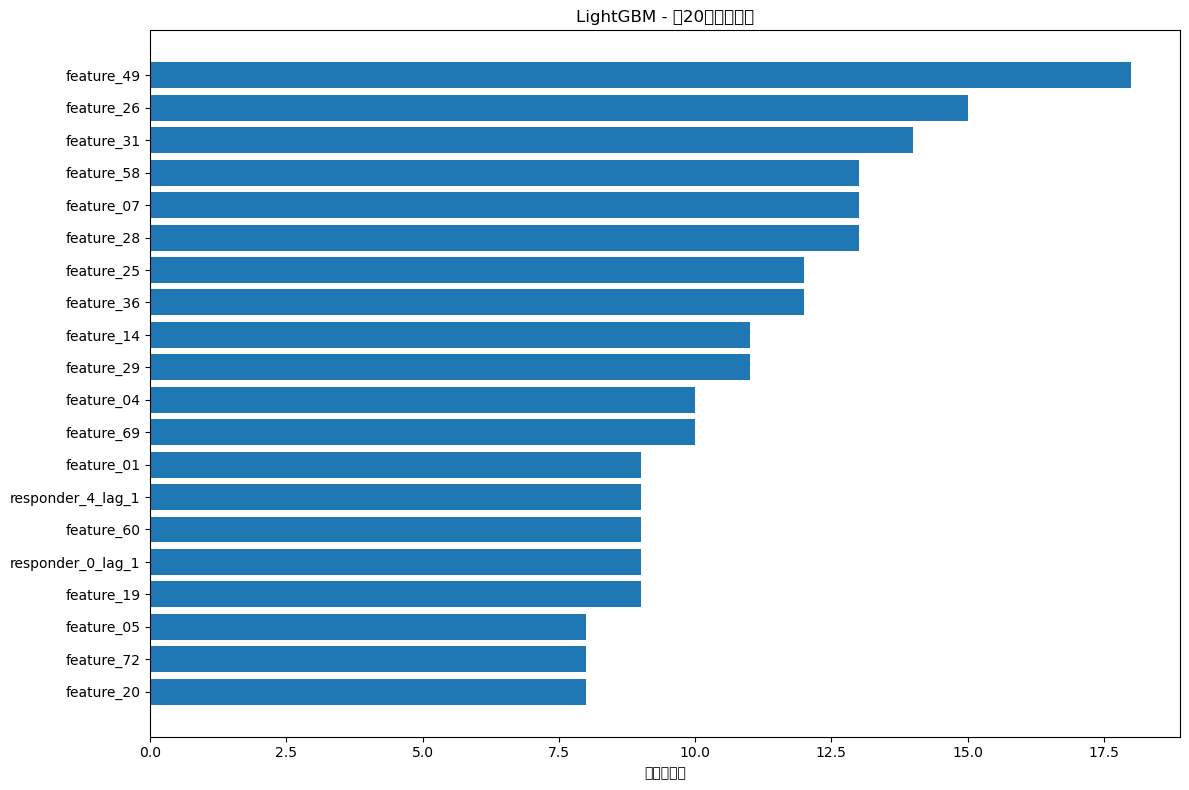


前20个重要特征:
              feature  importance
49         feature_49        18.0
26         feature_26        15.0
31         feature_31        14.0
58         feature_58        13.0
7          feature_07        13.0
28         feature_28        13.0
25         feature_25        12.0
36         feature_36        12.0
14         feature_14        11.0
29         feature_29        11.0
4          feature_04        10.0
69         feature_69        10.0
1          feature_01         9.0
83  responder_4_lag_1         9.0
60         feature_60         9.0
79  responder_0_lag_1         9.0
19         feature_19         9.0
5          feature_05         8.0
72         feature_72         8.0
20         feature_20         8.0


In [20]:
def analyze_feature_importance(models, top_n=20):
    """
    分析特征重要性
    
    参数:
        models: 训练好的模型列表
        top_n: 显示前n个重要特征
    """
    
    # 收集所有模型的特征重要性
    importance_list = []
    for i, model in enumerate(models):
        imp = model.feature_importances_
        importance_list.append(imp)
    
    # 平均特征重要性
    avg_importance = np.mean(importance_list, axis=0)
    
    # 创建DataFrame
    importance_df = pd.DataFrame({
        'feature': CONFIG.FEATURE_COLS,
        'importance': avg_importance
    })
    importance_df = importance_df.sort_values('importance', ascending=False)
    
    # 可视化
    plt.figure(figsize=(12, 8))
    plt.barh(range(top_n), importance_df['importance'].head(top_n)[::-1])
    plt.yticks(range(top_n), importance_df['feature'].head(top_n)[::-1])
    plt.xlabel('平均重要性')
    plt.title(f'LightGBM - 前{top_n}个重要特征')
    plt.tight_layout()
    plt.show()
    
    # 打印
    print(f"\n前{top_n}个重要特征:")
    print(importance_df.head(top_n))
    
    return importance_df

# 分析特征重要性
if 'models' in locals() and models:
    importance_df = analyze_feature_importance(models)

## 8. 按股票评估

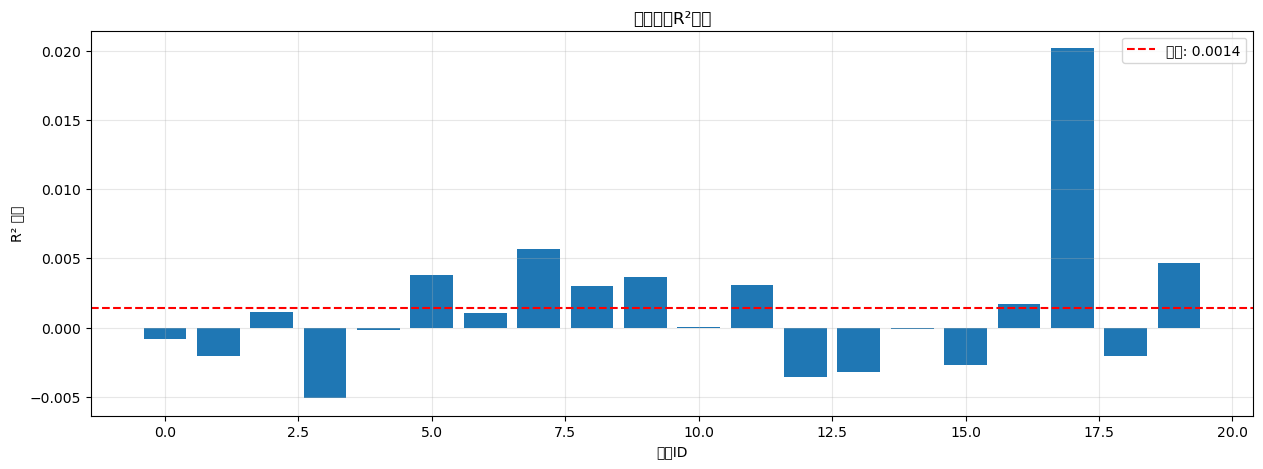


各股票R²得分:
股票  0: R² = -0.0009, 样本数 = 14520
股票  1: R² = -0.0020, 样本数 = 14520
股票  2: R² = 0.0011, 样本数 = 14520
股票  3: R² = -0.0051, 样本数 = 14520
股票  4: R² = -0.0002, 样本数 = 14520
股票  5: R² = 0.0038, 样本数 = 14520
股票  6: R² = 0.0010, 样本数 = 14520
股票  7: R² = 0.0057, 样本数 = 14520
股票  8: R² = 0.0030, 样本数 = 14520
股票  9: R² = 0.0036, 样本数 = 14520
股票 10: R² = 0.0000, 样本数 = 14520
股票 11: R² = 0.0030, 样本数 = 14520
股票 12: R² = -0.0036, 样本数 = 14520
股票 13: R² = -0.0032, 样本数 = 14520
股票 14: R² = -0.0001, 样本数 = 14520
股票 15: R² = -0.0027, 样本数 = 14520
股票 16: R² = 0.0017, 样本数 = 14520
股票 17: R² = 0.0202, 样本数 = 14520
股票 18: R² = -0.0020, 样本数 = 14520
股票 19: R² = 0.0047, 样本数 = 14520


In [21]:
def evaluate_by_symbol(models, df):
    """
    按股票评估模型性能
    """
    
    if valid_df is not None:
        eval_df = valid_df.copy()
    else:
        eval_df = train_df.copy()
    
    symbol_scores = {}
    
    for symbol_id in sorted(eval_df['symbol_id'].unique()):
        symbol_data = eval_df[eval_df['symbol_id'] == symbol_id]
        
        X = symbol_data[CONFIG.FEATURE_COLS]
        y = symbol_data[CONFIG.TARGET_COL]
        w = symbol_data[CONFIG.WEIGHT_COL]
        
        # 平均预测
        predictions = np.mean([model.predict(X) for model in models], axis=0)
        r2 = weighted_r2_score(y.values, predictions, w.values)
        
        symbol_scores[symbol_id] = {
            'r2': r2,
            'samples': len(symbol_data)
        }
    
    # 可视化
    symbols = list(symbol_scores.keys())
    scores = [symbol_scores[s]['r2'] for s in symbols]
    
    plt.figure(figsize=(15, 5))
    plt.bar(symbols, scores)
    plt.xlabel('股票ID')
    plt.ylabel('R² 得分')
    plt.title('各股票的R²得分')
    plt.axhline(y=np.mean(scores), color='red', linestyle='--', label=f'平均: {np.mean(scores):.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 打印统计
    print("\n各股票R²得分:")
    for symbol_id in symbols:
        info = symbol_scores[symbol_id]
        print(f"股票 {symbol_id:2d}: R² = {info['r2']:6.4f}, 样本数 = {info['samples']}")
    
    return symbol_scores

# 按股票评估
if 'models' in locals() and models:
    symbol_scores = evaluate_by_symbol(models, train_df)

## 9. 保存和加载模型

In [22]:
def save_training_info(models, cv_scores):
    """
    保存训练信息
    """
    import json
    
    training_info = {
        'model_type': 'LightGBM',
        'n_folds': CONFIG.N_FOLDS,
        'n_models': len(models),
        'cv_scores': cv_scores,
        'mean_cv_score': float(np.mean(cv_scores)),
        'std_cv_score': float(np.std(cv_scores)),
        'feature_cols': CONFIG.FEATURE_COLS,
        'target_col': CONFIG.TARGET_COL,
        'config': {
            'n_estimators': CONFIG.N_ESTIMATORS,
            'learning_rate': CONFIG.LEARNING_RATE,
            'max_depth': CONFIG.MAX_DEPTH,
            'num_leaves': CONFIG.NUM_LEAVES,
        }
    }
    
    # 保存为JSON
    info_path = MODEL_OUTPUT_PATH / 'lgb_training_info.json'
    with open(info_path, 'w') as f:
        json.dump(training_info, f, indent=2)
    
    print(f"训练信息已保存到: {info_path}")
    
    return training_info

# 保存训练信息
if 'models' in locals() and models:
    training_info = save_training_info(models, cv_scores)

训练信息已保存到: models/lgb_training_info.json


## 10. 总结和下一步

In [23]:
print("""
=== LightGBM训练总结 ===

1. 完成的工作:
   - 数据加载和预处理
   - 自定义加权R²评估指标
   - 交叉验证训练
   - 特征重要性分析
   - 按股票评估

2. 输出文件:
   - 模型文件: {}/lgb_model_*.pkl
   - 训练信息: {}/lgb_training_info.json

3. 下一步:
   - 尝试不同的模型架构（XGBoost、神经网络）
   - 调整超参数
   - 特征工程优化
   - 模型集成

4. 推理时的使用:
   - 加载训练好的模型
   - 处理lags数据
   - 进行预测
   - 对多个模型的预测结果进行平均
""".format(MODEL_OUTPUT_PATH, MODEL_OUTPUT_PATH))


=== LightGBM训练总结 ===

1. 完成的工作:
   - 数据加载和预处理
   - 自定义加权R²评估指标
   - 交叉验证训练
   - 特征重要性分析
   - 按股票评估

2. 输出文件:
   - 模型文件: models/lgb_model_*.pkl
   - 训练信息: models/lgb_training_info.json

3. 下一步:
   - 尝试不同的模型架构（XGBoost、神经网络）
   - 调整超参数
   - 特征工程优化
   - 模型集成

4. 推理时的使用:
   - 加载训练好的模型
   - 处理lags数据
   - 进行预测
   - 对多个模型的预测结果进行平均



## 附录：快速推理示例

In [24]:
def predict_with_lgb_model(test_df, lags_df, model_dir=MODEL_OUTPUT_PATH):
    """
    使用训练好的LightGBM模型进行预测
    
    参数:
        test_df: 测试数据
        lags_df: API提供的lags数据
        model_dir: 模型目录
    
    返回:
        预测结果
    """
    # 加载模型
    model_files = list(model_dir.glob('lgb_model_*.pkl'))
    models = [joblib.load(f) for f in model_files]
    
    # 处理lags
    responder_cols = [f'responder_{i}' for i in range(9)]
    existing_cols = [col for col in responder_cols if col in lags_df.columns]
    
    for col in existing_cols:
        lag_col = f'{col}_lag_1'
        test_df[lag_col] = test_df['symbol_id'].map(lags_df.set_index('symbol_id')[col])
    
    # 填充缺失值
    for col in CONFIG.FEATURE_COLS:
        if col in test_df.columns:
            test_df[col] = test_df[col].fillna(0)
    
    # 提取特征
    X = test_df[CONFIG.FEATURE_COLS]
    
    # 预测
    predictions = np.mean([model.predict(X) for model in models], axis=0)
    
    return predictions

print("\n推理函数已定义")
print("\n使用示例:")
print("""
predictions = predict_with_lgb_model(test, lags)
result = pd.DataFrame({
    'row_id': test['row_id'],
    'responder_6': predictions
})
""")


推理函数已定义

使用示例:

predictions = predict_with_lgb_model(test, lags)
result = pd.DataFrame({
    'row_id': test['row_id'],
    'responder_6': predictions
})

